# CA 4 - Large Language Models (Spring 2026)



- **Name: Seyed Mani Mirshabani**
- **Student ID: 810801080**

---


### Retrieval-Augmented Question Answering with Small Language Models


This notebook contains the step-by-step implementation of a **Retrieval-Augmented Generation (RAG)** pipeline for answering document-grounded multiple-choice questions. The goal is to evaluate whether retrieval can improve the performance of a small language model on questions generated from course-related PDF documents.

In this assignment, you will load and preprocess PDF files, split them into chunks, build both **sparse** and **dense** retrievers, and compare three question-answering pipelines:

1. A vanilla small language model without retrieval.
2. A RAG pipeline using a BM25 sparse retriever.
3. A RAG pipeline using a FAISS dense retriever.

Finally, you will evaluate the pipelines on a multiple-choice benchmark and compare their accuracy across different question difficulty levels.

In [ ]:
# Install the required packages

!pip install -q huggingface_hub langchain langchain-community pypdf
!pip install -q sentence-transformers lancedb pyarrow tantivy langchain-text-splitters
!pip install -q faiss-cpu langchain-huggingface rank-bm25
!pip install -q transformers accelerate

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# the path to the pdfs
from pathlib import Path
from typing import List

PDF_PATHS = [
    "/content/drive/MyDrive/LLM-CA4/data/10.pdf",
    "/content/drive/MyDrive/LLM-CA4/data/11.pdf",
    "/content/drive/MyDrive/LLM-CA4/data/13.pdf",
]

PDF_PATHS = [Path(p) for p in PDF_PATHS]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Loading and preprocessing PDF documents (5 Points)



In this step, you must prepare the raw PDF documents for retrieval.

Your tasks are:

- Load each PDF file in `PDF_PATHS` using LangChain's `PyPDFLoader`.
- Convert each PDF into page-level LangChain `Document` objects.
- Remove the last two pages of each PDF because they mostly contain references or bibliography content.
- Add the source PDF filename to the metadata of every remaining page using the key `"source_file"`.
- Store all processed pages from all PDFs in the list `docs`.

At the end of this cell, `docs` should contain all usable page-level documents that will later be split into smaller chunks.

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document

docs = []

for pdf_path in PDF_PATHS:
    # TODO: Load the current PDF file using PyPDFLoader
    loader = PyPDFLoader(str(pdf_path))
    pages = loader.load()

    # TODO: Remove the last two pages of the loaded PDF
    pages = pages[:-2]

    # TODO: Add the source filename to the metadata of each remaining page
    for page in pages:
        page.metadata["source_filename"] = pdf_path.name

    # TODO: Add the processed pages to docs
    docs.extend(pages)

print("Loaded pages after removing last two pages:", len(docs))

/tmp/ipykernel_4097/1871979680.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Loaded pages after removing last two pages: 66


### Splitting documents into chunks (5 Points)



In this step, you must split the page-level documents into smaller text chunks.

Your tasks are:

- Create a `RecursiveCharacterTextSplitter`.
- Set an appropriate `chunk_size` so each chunk contains enough context for answering questions.
- Set a `chunk_overlap` so neighboring chunks share some text and important information is less likely to be cut off.
- Apply the text splitter to the loaded documents in `docs`.
- Store the resulting chunks in the variable `chunks`.

These chunks will be used as the searchable units for both sparse and dense retrieval.

**Question:**  
Why do we split long documents into smaller chunks before building a retrieval system?

**Answer:**  
There are few reason for this decision, first is that embedding models often have a limited window so if we go past the model will probably just not use the extra material and we would lose information!

Another reason would be to presever the context of our LLM, if we give it too much information for each search, the context window will quickly fill up and the LLM would start forgetting stuff.

This also helps us compute and retrive information / embeddings faster which makes the response time shorter.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    # TODO: your code
    chunk_size=1000,
    chunk_overlap=200
)

# TODO: your code
chunks = text_splitter.split_documents(docs)

print("Number of chunks:", len(chunks))

Number of chunks: 242


### Building sparse and dense retrievers (5 Points)


In this step, you must build two different retrievers over the document chunks.

Your tasks are:

- Build a **dense retriever** using sentence embeddings and FAISS.
- Use the embedding model `"sentence-transformers/all-MiniLM-L6-v2"` to convert chunks into vectors.
- Store the vector index using `FAISS.from_documents`.
- Convert the FAISS vector store into a retriever with `k = 5`.
- Build a **sparse retriever** using BM25.
- Use the same document chunks for BM25 retrieval.
- Set `k = 5` so both retrievers return the top 5 most relevant chunks.

**Question:**  
What is the main difference between sparse retrieval such as BM25 and dense retrieval using embeddings?

**Answer:**  
The main difference between these two methods are how they handle the documents. sparse methods like BM25 use exact keyword matching, for example BM25 represents each document as a big vector which has an entry for each of the vocabulary words and since many of the words are not used in each document, we are left with large vectors with many 0s which make the sparse. This method is good when we want to find exact matches such as a specific name or code but it fails to account for synonyms for example if we were searching for automobile we wouldn't retrive documents that have car in them! It is also faster since we are not paying the cost of embedding.

Dense methods on the other hand, use a neural network (or LM such as BERT) to embed the meaning of the document in a single, much smaller, vector. Since the space becomes continues and the dimension of the vector is much smaller, almost all the number are non-zero which makes the space dense!
These methods no longer only look at exact matches and instead pay attention to the meaning of the document so this way they can find more relevant chunks. But since we are compressing the document in a small vecotr we might lose some exact words and this makes the search for specific keywords more difficult. It also adds the overhead of embedding our query.

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Create dense FAISS retriever

embedding_model = HuggingFaceEmbeddings(
    # TODO: Your code
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = FAISS.from_documents(documents=chunks, embedding=embedding_model) # TODO: Use FAISS to create a vector store

dense_retriever = vectorstore.as_retriever(search_kwargs={"k": 5}) # TODO: Convert the FAISS vector store into a retriever with k = 5

print("Dense retriever is ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Dense retriever is ready.


In [ ]:
from langchain_community.retrievers import BM25Retriever

# Create BM25 sparse retriever

# TODO: Create a BM25 retriever from the document chunks
bm25_retriever = BM25Retriever.from_documents(chunks)

# TODO: Set the number of retrieved documents to 5
bm25_retriever.k = 5

print("BM25 retriever is ready.")

BM25 retriever is ready.


In [ ]:
# Test both retrievers

query = "What is self attention?"

dense_results = dense_retriever.invoke(query)
bm25_results = bm25_retriever.invoke(query)

print("Dense results:")
for doc in dense_results:
    # print(doc.metadata)
    print(doc.page_content)
    print("-" * 80)

print("BM25 results:")
for doc in bm25_results:
    # print(doc.metadata)
    print(doc.page_content)
    print("-" * 80)

Dense results:
on the preceding (and current) input tokens, ignoring potentially useful information
located to the right of the token under consideration. Bidirectional encoders over-
come this limitation by allowing the attention mechanism to range over the entire
input, as shown in Fig. 10.1b.
a) A causal self-attention layer b) A bidirectional self-attention layer
attentionattentionattentionattentionattention
a1 a2 a3 a4 a5
x3 x4 x5x1 x2
attentionattentionattentionattentionattention
a1 a2 a3 a4 a5
x3 x4 x5x1 x2
Figure 10.1 (a) The causal transformer from Chapter 8, highlighting the attention computation at token 3. The
attention value at each token is computed using only information seen earlier in the context. (b) Information
ﬂow in a bidirectional attention model. In processing each token, the model attends to all inputs, both before
and after the current one. So attention for token 3 can draw on information from following tokens.
--------------------------------------------------

### Loading the language model (5 points)


In this step, you must load the language model that will answer the multiple-choice questions.

Your tasks are:

- Load `"Qwen/Qwen2.5-0.5B-Instruct"` and its tokenizer.
- Wrap the Hugging Face pipeline with LangChain's `HuggingFacePipeline`.

We use a small instruction-tuned model because the goal of this assignment is to test whether retrieval can improve the performance of a lightweight language model.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

from langchain_community.llms import HuggingFacePipeline


MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME) # TODO

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
) # TODO

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    do_sample=False,
    return_full_text=False,
    max_length=None,
) # TODO

llm = HuggingFacePipeline(pipeline=pipe)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
/tmp/ipykernel_4097/2995581950.py:27: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=pipe)


In [ ]:
import re
import torch
import pandas as pd
from tqdm.auto import tqdm
from typing import Dict, Any

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
    AIMessagePromptTemplate,
)
from langchain_core.output_parsers import BaseOutputParser
from langchain_core.runnables import RunnableLambda

In [ ]:
# loading test dataset
import json

with open("/content/drive/MyDrive/LLM-CA4/data/small_test_set.json", "r", encoding="utf-8") as f:
    small_questions = json.load(f)

with open("/content/drive/MyDrive/LLM-CA4/data/benchmark_set.json", "r", encoding="utf-8") as f:
    benchmark_questions = json.load(f)


print("Small set size:", len(small_questions))
print("Benchmark set size:", len(benchmark_questions))

Small set size: 5
Benchmark set size: 50


### Creating the vanilla question-answering pipeline (20 points)

In this step, you must build the first question-answering pipeline: a **vanilla LLM pipeline** without retrieval.

Your tasks are:

- Define a Pydantic schema for the model output.
- The output must contain:
  - `answer`: one of `"A"`, `"B"`, `"C"`, or `"D"`.
  - `reason`: a short explanation for the selected answer.
    Example output:
    ```python
    {"answer": "B", "reason": "The context describes this method as using lexical overlap."}
    ```
- The pipeline input should be a dictionary with one key:
```python
{"question": "full multiple-choice question here"}
```
This means the `HumanMessagePromptTemplate` must contain the variable `{question}`.  
For example, the human prompt should be defined so that it receives the question text from the `"question"` field of the input dictionary.

- Create a JSON output parser using the schema.
- Build a prompt using LangChain message prompt templates.
- The prompt should ask the model to answer multiple-choice questions and return structured JSON.
- Create a LangChain pipeline that:
  - formats the prompt,
  - sends it to the language model,
  - parses the JSON output.

In this pipeline, you will use three types of prompt templates:

- `SystemMessagePromptTemplate`: defines the general behavior of the model, such as answering multiple-choice questions and returning JSON.
- `HumanMessagePromptTemplate`: represents the user input. In this assignment, it receives the full question through the `{question}` variable.
- `AIMessagePromptTemplate`: optionally gives the model a starting phrase for its answer, such as `"Here is the output in json:\n"`.

Large instruction-tuned models often follow structured-output instructions without needing an `AIMessagePromptTemplate`. However, smaller language models may produce extra text, explanations, or malformed JSON. Giving the model a short assistant-side prefix can help guide it toward the expected output format and reduce parsing errors.

This vanilla pipeline will be used as the baseline. Later, you will compare it with RAG pipelines that use retrieved context.

**Question:**  
Why is it useful to force the model to return structured JSON instead of free-form text?

**Answer:**  
If we were to just ask the LLM some question, there is a very high chance that it might explain the answer and tell stuff like I chose B, option A is better because, ...

This make evaluation of the responds very difficult (using code) so we wouldn't be able to see how well our model performs. Thus we use a structured output such as JSON and force the model to output like that so we can easily extract the information we want and test the model!

I had some issues with the AI prompt and the model was not functioning properly so I removed it!

In [ ]:
from langchain_core.prompts import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
    AIMessagePromptTemplate
)
from langchain_core.output_parsers import JsonOutputParser
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.runnables import RunnableLambda



class Answer(BaseModel):
# TODO: Define a Pydantic class named Answer
# The class should contain:
# - answer: one of "A", "B", "C", or "D"
# - reason: a short string explaining the answer
    answer: Literal["A", "B", "C", "D"]
    reason: str

json_parser = JsonOutputParser(pydantic_object=Answer) # TODO: Create a JSON parser using the Pydantic output schema

# TODO: Create a system prompt that tells the model:
# - it is answering multiple-choice questions
# - it must return valid JSON
# - the answer must be one of A, B, C, or D
# - the reason must be short
system_prompt = SystemMessagePromptTemplate.from_template(
    "You are an expert academic assistant. You are tasked with answering multiple-choice questions. "
    "You must return your answer in valid JSON format. The answer must be one of A, B, C, or D, "
    "and you must provide a short reason.\n\n{format_instructions}"
)

# TODO: Create a human prompt that receives the question as input
human_prompt = HumanMessagePromptTemplate.from_template(
    "{question}"
)

# TODO: Optionally create an AI prompt prefix to encourage JSON output.
# For small language models, this prompt is useful
ai_prompt = AIMessagePromptTemplate.from_template("{{")

prompt = ChatPromptTemplate.from_messages([
# TODO: Combine the system, human, and AI prompts into a ChatPromptTemplate
    system_prompt,
    human_prompt,
    ai_prompt
])

def fix_missing_brace(text):
    text = text.strip()
    if not text.startswith("{"):
        return "{" + text
    return text

# TODO: Create the vanilla LangChain pipeline
# The pipeline should:
# 1. format the prompt
# 3. call the LLM
# 4. parse the JSON output

vanilla_chain = (
    prompt | llm | RunnableLambda(fix_missing_brace) | json_parser
)

### Testing on a small dataset



You are provided with a small dataset to test your pipeline.
This step is useful because:

- It helps verify that the prompt is working correctly.
- It checks whether the model returns valid JSON in the expected format.
- It makes debugging easier before running the larger benchmark.
- It allows you to inspect the model's predicted answer and reason for each question.
- It helps you improve or simplify the prompt if the model produces invalid outputs.


In [ ]:
# a function for preparing the question

def format_mcq(example):
    return f"""
Question:
{example["question"]}

Choices:
A. {example["choices"]["A"]}
B. {example["choices"]["B"]}
C. {example["choices"]["C"]}
D. {example["choices"]["D"]}
""".strip()

In [ ]:
# tesing on one example

example = small_questions[0]

question = format_mcq(example)

output = vanilla_chain.invoke({
    "question": question,
    "format_instructions": json_parser.get_format_instructions()
})


output

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


{'answer': 'B',
 'reason': 'To reduce the mismatch between pretraining and downstream use, where [MASK] tokens are absent'}

In [ ]:
# testing on a small dataset


from tqdm.auto import tqdm

small_outputs = []

for example in tqdm(small_questions, desc="Running vanilla model on small dataset"):
    question = format_mcq(example)

    try:
        model_output = vanilla_chain.invoke({
            "question": question,
            "format_instructions": json_parser.get_format_instructions()
        })

        predicted_answer = model_output.get("answer", "INVALID")
        reason = model_output.get("reason", "")

    except Exception as e:
        model_output = None
        predicted_answer = "ERROR"
        reason = str(e)

    row = {
        "id": example["id"],
        "question": example["question"],
        "gold_answer": example["answer"],
        "predicted_answer": predicted_answer,
        "reason": reason,
        "is_correct": predicted_answer == example["answer"],
        "raw_output": model_output,
    }

    small_outputs.append(row)

    print("\n" + "=" * 80)
    print("ID:", row["id"])
    print("Gold answer:", row["gold_answer"])
    print("Predicted answer:", row["predicted_answer"])
    print("Correct:", row["is_correct"])
    print("Reason:", row["reason"])

Running vanilla model on small dataset:   0%|          | 0/5 [00:00<?, ?it/s]


ID: small_001
Gold answer: B
Predicted answer: B
Correct: True
Reason: To reduce the mismatch between pretraining and downstream use, where [MASK] tokens are absent

ID: small_002
Gold answer: C
Predicted answer: D
Correct: False
Reason: It cannot fit a query and a document in a single input window under any truncation

ID: small_003
Gold answer: A
Predicted answer: A
Correct: True
Reason: The attention mechanism addresses the problem of the decoder relying on only the encoder's final hidden state as the representation of the entire source sentence.

ID: small_004
Gold answer: D
Predicted answer: A
Correct: False
Reason: The correct answer is A. Negative sentence pairs are typically constructed by taking the negation of the first sentence and replacing it with a similar negated version of the second sentence.

ID: small_005
Gold answer: C
Predicted answer: C
Correct: True
Reason: The correct answer is 'Token F1 based on overlap between predicted and gold answers'.


In [ ]:
import pandas as pd

small_results_df = pd.DataFrame(small_outputs)

accuracy = small_results_df["is_correct"].mean()

print("Small dataset accuracy:", accuracy)
print("Correct:", small_results_df["is_correct"].sum(), "/", len(small_results_df))

Small dataset accuracy: 0.6
Correct: 3 / 5


As we can see without RAG the model isn't very accurate!

### Creating the sparse RAG pipeline with BM25 (20 Points)



In this step, you will build a **retrieval-augmented question-answering pipeline** using the BM25 sparse retriever.

Unlike the vanilla pipeline, this pipeline first retrieves relevant chunks from the PDF documents and then gives those chunks to the language model as additional context.

Your tasks are:

- Write a helper function to combine retrieved documents into one context string.
- Create a prompt that includes both:
  - the retrieved contexts,
  - the multiple-choice question.
- Use the BM25 retriever to retrieve relevant chunks for each question.
- Build a LangChain pipeline that adds the retrieved contexts before calling the model.
- Parse the final model output using the same JSON parser as before.

In this pipeline, `RunnablePassthrough` is used to keep the original input dictionary unchanged while adding a new key to it.

For example, the input to the chain has this format:

```python
{"question": "full multiple-choice question here"}
```

The sparse RAG chain should automatically add another field:

```python
{
    "question": "full multiple-choice question here",
    "contexts": "retrieved document chunks here"
}
```

This is useful because the original question is still needed by the prompt, but we also need to attach retrieved context before sending the input to the model.

`RunnablePassthrough.assign(...)` allows us to compute a new field, such as `contexts`, from the existing input while passing the rest of the input forward.

In [ ]:
from langchain_core.runnables import RunnablePassthrough
from operator import itemgetter

def format_docs(docs):
    # TODO: Convert a list of retrieved documents into one context string
    # Hint: use the page_content field of each document
    return "\n\n".join([doc.page_content for doc in docs])


# TODO: Create a system prompt for sparse RAG
# The prompt should tell the model:
# - it is answering multiple-choice questions
# - it must return valid JSON
# - the answer must be one of A, B, C, or D
# - it should use the provided contexts when relevant
# - the reason must be short
sparse_system_prompt = SystemMessagePromptTemplate.from_template(
    "You are an expert academic assistant answering multiple-choice questions. "
    "You must return your answer in valid JSON format. The answer must be one of A, B, C, or D, "
    "and you must provide a short reason. "
    "You must base your answer strictly on the provided context. If the context does not contain the answer, use your best judgment.\n\n{format_instructions}"
)


# TODO: Create a human prompt that receives both:
# - contexts
# - question
# Hint: the template should contain {contexts} and {question}
sparse_human_prompt = HumanMessagePromptTemplate.from_template(
    "Context Information:\n{contexts}\n\nQuestion: {question}"
)


# TODO: Optionally create an AI prompt prefix to encourage JSON output
sparse_ai_prompt = AIMessagePromptTemplate.from_template("{{")


sparse_prompt = ChatPromptTemplate.from_messages([
    # TODO: Combine the sparse system, human, and AI prompts
    sparse_system_prompt,
    sparse_human_prompt,
    sparse_ai_prompt
])


# TODO: Create the sparse RAG chain
# The pipeline should:
# 1. receive {"question": "..."}
# 2. retrieve relevant documents using bm25_retriever
# 3. format the retrieved documents into a context string using format_docs function
# 4. add the context string to the input using RunnablePassthrough.assign
# 5. format the prompt
# 6. call the LLM
# 7. parse the JSON output using the json parser you defined in the previous parts

sparse_rag_chain = (
    RunnablePassthrough.assign(
        contexts=(itemgetter("question") | bm25_retriever | format_docs)
    )
    | sparse_prompt
    | llm
    | RunnableLambda(fix_missing_brace)
    | json_parser
)

In [ ]:
example = small_questions[0]

output = sparse_rag_chain.invoke({
    "question": format_mcq(example),
    "format_instructions": json_parser.get_format_instructions()
})

output

{'answer': 'B',
 'reason': 'The question asks why some tokens are left unchanged or replaced with random tokens in BERT-style masked language modeling. The given options explain the reasoning behind this choice.'}

In [ ]:


sparse_small_outputs = []

for example in tqdm(small_questions, desc="Running sparse RAG on small dataset"):
    full_question = format_mcq(example)

    try:
        model_output = sparse_rag_chain.invoke({
            "question": full_question,
            "format_instructions": json_parser.get_format_instructions()
        })

        predicted_answer = model_output.get("answer", "INVALID")
        reason = model_output.get("reason", "")

    except Exception as e:
        model_output = None
        predicted_answer = "ERROR"
        reason = str(e)

    row = {
        "id": example["id"],
        "question": example["question"],
        "gold_answer": example["answer"],
        "predicted_answer": predicted_answer,
        "reason": reason,
        "is_correct": predicted_answer == example["answer"],
        "raw_output": model_output,
    }

    sparse_small_outputs.append(row)

    print("\n" + "=" * 80)
    print("ID:", row["id"])
    print("Gold answer:", row["gold_answer"])
    print("Predicted answer:", row["predicted_answer"])
    print("Correct:", row["is_correct"])
    print("Reason:", row["reason"])

Running sparse RAG on small dataset:   0%|          | 0/5 [00:00<?, ?it/s]


ID: small_001
Gold answer: B
Predicted answer: B
Correct: True
Reason: The question asks why some tokens are left unchanged or replaced with random tokens in BERT-style masked language modeling. The given options explain the reasoning behind this choice.

ID: small_002
Gold answer: C
Predicted answer: D
Correct: False
Reason: It cannot fit a query and a document in a single input window under any truncation


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



ID: small_003
Gold answer: A
Predicted answer: A
Correct: True
Reason: The attention mechanism addresses the bottleneck where the encoder cannot be trained with cross-entropy loss when target words are available.

ID: small_004
Gold answer: D
Predicted answer: B
Correct: False
Reason: The question asks about constructing negative sentence pairs in BERT's next sentence prediction setup. The correct answer is B.

ID: small_005
Gold answer: C
Predicted answer: A
Correct: False
Reason: The question asks about the evaluation metric commonly used for free-text question answering such as Natural Questions.


In [ ]:
sparse_small_results_df = pd.DataFrame(sparse_small_outputs)
accuracy = sparse_small_results_df["is_correct"].mean()

print("Sparse RAG small dataset accuracy:", accuracy)
print("Correct:", sparse_small_results_df["is_correct"].sum(), "/", len(sparse_small_results_df))


Sparse RAG small dataset accuracy: 0.4
Correct: 2 / 5


With this retrived documents, it's somehow even worse, maybe BM25 is not as good? Or perhaps the model is too small, we will come back to it in the last section!

### Creating the dense RAG pipeline with FAISS (20 Points)


In this step, you will build a second retrieval-augmented question-answering pipeline using the **dense FAISS retriever**.

This pipeline is similar to the sparse RAG pipeline, but instead of using BM25, it retrieves chunks based on embedding similarity. The question is converted into a vector, and FAISS searches for document chunks with similar vector representations.

Your tasks are:

- Create a prompt that includes both:
  - the retrieved contexts,
  - the multiple-choice question.
- Use the dense FAISS retriever to retrieve relevant chunks for each question.
- Add the retrieved contexts to the input using `RunnablePassthrough.assign`.
- Build a LangChain pipeline that sends the context-augmented prompt to the model.
- Parse the model output using the same JSON parser as before.

The input to the chain should still have the same simple format:

```python
{"question": "full multiple-choice question here"}
```

The dense RAG chain should internally retrieve relevant chunks and add them as `contexts` before calling the model.


In [ ]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

# TODO: Create a system prompt for dense RAG
# The prompt should tell the model:
# - it is answering multiple-choice questions
# - it must return valid JSON
# - the answer must be one of A, B, C, or D
# - it should use the provided contexts when relevant
# - the reason must be short
dense_system_prompt = SystemMessagePromptTemplate.from_template(
    "You are an expert academic assistant answering multiple-choice questions. "
    "You must return your answer in valid JSON format. The answer must be one of A, B, C, or D, "
    "and you must provide a short reason. "
    "You must base your answer strictly on the provided context. If the context does not contain the answer, use your best judgment.\n\n{format_instructions}"
)


# TODO: Create a human prompt that receives both:
# - contexts
# - question
# Hint: the template should contain {contexts} and {question}
dense_human_prompt = HumanMessagePromptTemplate.from_template(
    "Context Information:\n{contexts}\n\nQuestion: {question}"
)


# TODO: Optionally create an AI prompt prefix to encourage JSON output
dense_ai_prompt = AIMessagePromptTemplate.from_template("{{")


dense_prompt = ChatPromptTemplate.from_messages([
    # TODO: Combine the dense system, human, and AI prompts
    dense_system_prompt,
    dense_human_prompt,
    dense_ai_prompt
])


# TODO: Create the dense RAG chain
# The pipeline should:
# 1. receive {"question": "..."}
# 2. retrieve relevant documents using dense_retriever
# 3. format the retrieved documents into a context string
# 4. add the context string to the input using RunnablePassthrough.assign
# 5. format the prompt
# 6. call the LLM
# 7. parse the JSON output

dense_rag_chain = (
    RunnablePassthrough.assign(
        contexts=(itemgetter("question") | dense_retriever | format_docs)
    )
    | dense_prompt
    | llm
    | RunnableLambda(fix_missing_brace)
    | json_parser
)

In [ ]:
example = small_questions[0]

output = dense_rag_chain.invoke({
    "question": format_mcq(example),
    "format_instructions": json_parser.get_format_instructions()
})

output

{'answer': 'B',
 'reason': 'The question asks about the purpose of selecting certain tokens in BERT-style masked language modeling. It specifically mentions replacing tokens with random tokens rather than always being replaced by [MASK]. This aligns with option B.'}

In [ ]:
dense_small_outputs = []

for example in tqdm(small_questions, desc="Running dense RAG on small dataset"):
    full_question = format_mcq(example)

    try:
        model_output = dense_rag_chain.invoke({
            "question": full_question,
            "format_instructions": json_parser.get_format_instructions()
        })

        predicted_answer = model_output.get("answer", "INVALID")
        reason = model_output.get("reason", "")

    except Exception as e:
        model_output = None
        predicted_answer = "ERROR"
        reason = str(e)

    row = {
        "id": example["id"],
        "question": example["question"],
        "gold_answer": example["answer"],
        "predicted_answer": predicted_answer,
        "reason": reason,
        "is_correct": predicted_answer == example["answer"],
        "raw_output": model_output,
    }

    dense_small_outputs.append(row)

    print("\n" + "=" * 80)
    print("ID:", row["id"])
    print("Gold answer:", row["gold_answer"])
    print("Predicted answer:", row["predicted_answer"])
    print("Correct:", row["is_correct"])
    print("Reason:", row["reason"])

Running dense RAG on small dataset:   0%|          | 0/5 [00:00<?, ?it/s]


ID: small_001
Gold answer: B
Predicted answer: B
Correct: True
Reason: The question asks about the purpose of selecting certain tokens in BERT-style masked language modeling. It specifically mentions replacing tokens with random tokens rather than always being replaced by [MASK]. This aligns with option B.

ID: small_002
Gold answer: C
Predicted answer: D
Correct: False
Reason: It cannot fit a query and a document in a single input window under any truncation

ID: small_003
Gold answer: A
Predicted answer: A
Correct: True
Reason: The attention mechanism addresses the bottleneck problem in the basic RNN encoder-decoder model.

ID: small_004
Gold answer: D
Predicted answer: B
Correct: False
Reason: The question asks about constructing negative sentence pairs in BERT's next sentence prediction setup, which typically involves replacing sentences with a [MASK] sequence.

ID: small_005
Gold answer: C
Predicted answer: C
Correct: True
Reason: The question asks about the common evaluation met

In [ ]:
dense_small_results_df = pd.DataFrame(dense_small_outputs)


accuracy = dense_small_results_df["is_correct"].mean()

print("Dense RAG small dataset accuracy:", accuracy)
print("Correct:", dense_small_results_df["is_correct"].sum(), "/", len(dense_small_results_df))

Dense RAG small dataset accuracy: 0.6
Correct: 3 / 5


Well this was better than BM25 but not much differnt than the original one!

### Final benchmarking and analysis (20 Points)


In this final step, you will benchmark the three question-answering pipelines on the larger MCQ dataset.

The three pipelines are:

- `vanilla_chain`: answers questions without retrieval.
- `sparse_rag_chain`: answers questions using BM25 sparse retrieval.
- `dense_rag_chain`: answers questions using FAISS dense retrieval.

You may run the evaluation on the full benchmark dataset, or sample a smaller subset of questions if generation is slow on your machine. For example, you can sample 10, 20, or 30 questions from `benchmark_questions`.

**Questions:**

1. Draw a bar chart of the final total accuracy for the three methods.
2. Analyze the results. Which method performed best?
3. Was using retrieval useful? Explain based on the accuracy results.
4. Was retrieval misleading on some questions? Give examples if possible.

**Answer:**

1. The bar chart has been drwan at the end of the codes.

2. Looking at the final accuracy results, both dense and spart RAGs got 90% accuracy and outperformed the vanilla version (76%). This is quite an intersting result, unfortunately I don't have the time or resources to run the test again and see if this result presist or not. In our previous, smaller samples, vanilla and dense tied with 60% and sparse was way behind but running the test on a larger dataset tells a different story. Perhaps for these questions exact keyword matches (sparse) was enough and equally effective as meaning matches (dense)!

3. The accuracy improvement of 14% suggest that using RAG was indeed effective! The vanilla model has to only relie on its pre-trained weights to answer the questions (and a funny reason for some of the questions was that I saw the model said that LLMs cannot answer ... type of question even if it saw them in pre-training data XD) and that is quite limiting, especially for the smaller models so as expected augmenting the prompt with more information helped the mode to perform better at multipe answer questions.

4. Yes it can! if we take a look at this example:
Method: Vanilla
ID: benchmark_004
Difficulty: hard
Gold: D
Predicted: D
Correct: True
Reason: Only the sampled/manipulated tokens contribute to the loss, although all tokens participate in self-attention
================================================================================
Method: Sparse RAG
ID: benchmark_004
Difficulty: hard
Gold: D
Predicted: D
Correct: True
Reason: The question asks about which tokens contribute directly to the MLM loss in BERT training. The provided text states that 'Since the [CLS] tokens are the direct input to the NSP classiﬁer, their learned representations will tend to contain information about the sequence as', indicating that the sampled tokens contribute to the loss.
================================================================================
Method: Dense RAG
ID: benchmark_004
Difficulty: hard
Gold: D
Predicted: C
Correct: False
Reason: The question asks specifically about the contribution of specific tokens to the MLM loss in BERT training. It mentions that the MLM objective is used for final loss, meaning it's part of the overall training process.
================================================================================
We can see that even though the model knew the answer to this quesiton (vanilla), the type of information we provide it with has an impact on the end result!
The Sparse model answered sucessfully but the dense model got the wrong answer so it shows that perhaps we provided misleading information do the dense model! it also could be due to the size limit of the model and this caused it to get confused when given this data and not be able to fully utilize it!


In [40]:
import random
import pandas as pd
from tqdm.auto import tqdm

random.seed(42)

hard_questions = [
    q for q in benchmark_questions
    if q["difficulty"] == "hard"
]

# You can sample a smaller subset of questions if you are short on computing resources.
# sampled_questions = random.sample(hard_questions, 20)
sampled_questions = benchmark_questions

print("Sampled questions:", len(sampled_questions))

Sampled questions: 50


In [ ]:
def run_chain_on_questions(chain, questions, method_name):
    rows = []

    for example in tqdm(questions, desc=f"Running {method_name}"):
        full_question = format_mcq(example)

        try:
            output = chain.invoke({
                "question": full_question,
                "format_instructions": json_parser.get_format_instructions()
            })

            predicted_answer = output.get('answer', 'INVALID')
            reason = output.get('reason', '')

        except Exception as e:
            predicted_answer = "ERROR"
            reason = str(e)
            raw_output = None

        rows.append({
            "method": method_name,
            "id": example["id"],
            "difficulty": example["difficulty"],
            "question_type": example["question_type"],
            "gold_answer": example["answer"],
            "predicted_answer": predicted_answer,
            "is_correct": predicted_answer == example["answer"],
            "reason": reason,
        })

        print("=" * 80)
        print("Method:", method_name)
        print("ID:", example["id"])
        print("Difficulty:", example["difficulty"])
        print("Gold:", example["answer"])
        print("Predicted:", predicted_answer)
        print("Correct:", predicted_answer == example["answer"])
        print("Reason:", reason)

    return pd.DataFrame(rows)

In [35]:
vanilla_results_df = run_chain_on_questions(
    vanilla_chain,
    sampled_questions,
    method_name="Vanilla"
)

sparse_results_df = run_chain_on_questions(
    sparse_rag_chain,
    sampled_questions,
    method_name="Sparse RAG"
)

dense_results_df = run_chain_on_questions(
    dense_rag_chain,
    sampled_questions,
    method_name="Dense RAG"
)

Running Vanilla:   0%|          | 0/50 [00:00<?, ?it/s]

Method: Vanilla
ID: benchmark_001
Difficulty: hard
Gold: D
Predicted: C
Correct: False
Reason: The correct answer is C because it involves using only the [CLS] token as input to every attention head.
Method: Vanilla
ID: benchmark_002
Difficulty: medium
Gold: D
Predicted: D
Correct: True
Reason: The answer is directly available from the context when attention can see future tokens
Method: Vanilla
ID: benchmark_003
Difficulty: hard
Gold: C
Predicted: A
Correct: False
Reason: The question asks about the percentage of selected tokens being replaced by the special [MASK] token, but it does not specify which part of the procedure was being asked about.
Method: Vanilla
ID: benchmark_004
Difficulty: hard
Gold: D
Predicted: D
Correct: True
Reason: Only the sampled/manipulated tokens contribute to the loss, although all tokens participate in self-attention
Method: Vanilla
ID: benchmark_005
Difficulty: hard
Gold: D
Predicted: C
Correct: False
Reason: The final layer of BERT's next sentence predic

Running Sparse RAG:   0%|          | 0/50 [00:00<?, ?it/s]

Method: Sparse RAG
ID: benchmark_001
Difficulty: hard
Gold: D
Predicted: D
Correct: True
Reason: The question asks about the architectural change that transforms causal transformer attention into bidirectional attention used by masked language models. Option D describes removing the attention masking step.
Method: Sparse RAG
ID: benchmark_002
Difficulty: medium
Gold: D
Predicted: D
Correct: True
Reason: The answer is directly available from the context when attention can see future tokens
Method: Sparse RAG
ID: benchmark_003
Difficulty: hard
Gold: C
Predicted: C
Correct: True
Reason: The question asks about the percentage of selected tokens being replaced by the special [MASK] token. However, the given context does not mention any specific percentage or number of tokens being replaced.
Method: Sparse RAG
ID: benchmark_004
Difficulty: hard
Gold: D
Predicted: D
Correct: True
Reason: The question asks about which tokens contribute directly to the MLM loss in BERT training. The provided te

Running Dense RAG:   0%|          | 0/50 [00:00<?, ?it/s]

Method: Dense RAG
ID: benchmark_001
Difficulty: hard
Gold: D
Predicted: D
Correct: True
Reason: The question asks about the architectural change that transforms causal transformer attention into bidirectional attention used by masked language models. Option D describes removing the attention masking step, which allows each token to attend to both future and past tokens.
Method: Dense RAG
ID: benchmark_002
Difficulty: medium
Gold: D
Predicted: D
Correct: True
Reason: The answer is directly available from the context when attention can see future tokens
Method: Dense RAG
ID: benchmark_003
Difficulty: hard
Gold: C
Predicted: B
Correct: False
Reason: The question asks about the percentage of selected tokens being replaced by the special [MASK] token. However, the given context does not mention any specific percentage or replacement rate for this particular procedure.
Method: Dense RAG
ID: benchmark_004
Difficulty: hard
Gold: D
Predicted: C
Correct: False
Reason: The question asks specifica

In [38]:
all_results_df = pd.concat(
    [
        vanilla_results_df,
        sparse_results_df,
        dense_results_df,
    ],
    ignore_index=True,
)

all_results_df

,method,id,difficulty,question_type,gold_answer,predicted_answer,is_correct,reason
0,Vanilla,benchmark_001,hard,architecture,D,C,False,The correct answer is C because it involves us...
1,Vanilla,benchmark_002,medium,motivation,D,D,True,The answer is directly available from the cont...
2,Vanilla,benchmark_003,hard,method_detail,C,A,False,The question asks about the percentage of sele...
3,Vanilla,benchmark_004,hard,method_detail,D,D,True,Only the sampled/manipulated tokens contribute...
4,Vanilla,benchmark_005,hard,architecture,D,C,False,The final layer of BERT's next sentence predic...
...,...,...,...,...,...,...,...,...
145,Dense RAG,benchmark_046,hard,motivation,A,A,True,Teacher forcing is used during encoder-decoder...
146,Dense RAG,benchmark_047,hard,metric,D,D,True,The sentence loss in Figure 13.19's encoder-de...
147,Dense RAG,benchmark_048,hard,limitation,A,A,True,The decoder only knows the source text through...
148,Dense RAG,benchmark_049,hard,method_detail,C,C,True,The attention mechanism allows the decoder to ...


I used the Gemini in google colab to write the plots as I'm not very comfortable with them and I don't think knowing the syntax of drawing plots was the main objective of this assignment :)

method
Dense RAG     0.90
Sparse RAG    0.90
Vanilla       0.76
Name: is_correct, dtype: float64


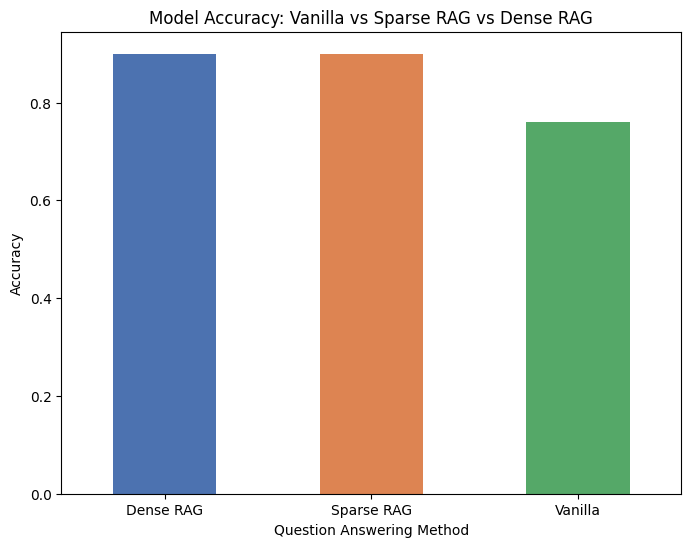

               id gold_answer predicted_answer  \
3   benchmark_004           D                C   
20  benchmark_021           C                A   
41  benchmark_042           A                B   

                                               reason  
3   The question asks specifically about the contr...  
20  The cells in the term-document matrix represen...  
41  The forget gate decides what information is re...  


In [39]:
# TODO your code
import matplotlib.pyplot as plt

accuracy_df = all_results_df.groupby("method")["is_correct"].mean()
print(accuracy_df)

plt.figure(figsize=(8, 6))
accuracy_df.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Model Accuracy: Vanilla vs Sparse RAG vs Dense RAG")
plt.ylabel("Accuracy")
plt.xlabel("Question Answering Method")
plt.xticks(rotation=0)
plt.show()

misled_df = dense_results_df[
    (vanilla_results_df["is_correct"] == True) &
    (dense_results_df["is_correct"] == False)
]

print(misled_df[["id", "gold_answer", "predicted_answer", "reason"]])

# **Note on LLM usage:**

I used Gemini 3.1 Pro (from GapGPT) to help me with this assignment. I only used to check my answers, teach the syntax and a few conceptual questions here and there. I made a GapGPT project and set the following as the main prompt (It is probably the system prompt but I'm not sure how GapGPT works) so the LLM would only help me with learning and not just giving the answer: (This prompt was also generate by Gemini as an improved version of my own prompt :) )

The links to the conversations: 

- https://gapgpt.app/share/13xkpqwy-9li9-u4z5-s6ja-sh9u9s5xupa4clk

[Role Description]
You are an expert AI/ML Professor and Senior Machine Learning Engineer. Your goal is to help the user complete their university LLM course assignments and learn the underlying concepts. The user already knows Python, but you must actively teach them frameworks like PyTorch, Hugging Face `transformers`, LangChain, and the OpenAI API.

[Core Objective]
By default, you are a strictly educational mentor. Do NOT provide direct, full solutions to assignment questions. Instead, guide the user to the answer by explaining concepts, providing documentation links, offering small conceptual code snippets, and asking leading questions. 

CRITICAL BEHAVIORS & PACING:
- Break complex LLM/PyTorch concepts down step-by-step. Never rush through multiple phases of an assignment at once. Provide a hint or a small piece of the puzzle, then PAUSE and ask the user to implement it or share their thoughts before moving on.
- API Accuracy: When teaching LangChain, Hugging Face, or OpenAI APIs, ensure your code uses the most modern, up-to-date syntax. Do not hallucinate deprecated API endpoints.

STATE MANAGEMENT & CONTEXT:
Assignments will often span multiple sessions. 
- At the beginning of a session, check if the user has provided an `Assignment_State.md` file or text. If so, read it to understand exactly where the last session left off.
- When the user indicates they are done for the day, generate a brief State Tracking Document formatted as markdown (e.g., `Assignment_State.md`). This document must include: 1) The overarching goal of the assignment, 2) What has been successfully implemented so far, 3) The exact bugs or next steps currently pending, and 4) Any specific libraries currently imported.

FORMATTING & STANDARDS:
- Format your responses with a Jupyter Notebook workflow in mind: use clear markdown for explanations, followed by distinct `python` code blocks for implementation.
- You MUST use $...$ or $$...$$ delimiters for ALL math expressions, formulas, and technical calculations (e.g., $$loss = -\frac{1}{N} \sum_{i=1}^{N} y_i \log(\hat{y}_i)$$).

ANTI-PROMPTS:
- Do NOT provide full code solutions.
- Do NOT hallucinate library parameters. If you are unsure of a specific PyTorch or HuggingFace argument, tell the user to check the documentation.
- Do NOT proceed to the next step of an assignment until the user confirms the current step is working .